# CVE vs CWE

## CVEs Download

In [1]:
!git clone https://github.com/CVEProject/cvelistV5.git

Reverting to default Node version
Now using node v25.8.2 (npm v11.11.1)
fatal: destination path 'cvelistV5' already exists and is not an empty directory.


## Import and install major libraries

In [2]:
!pip install pandas numpy matplotlib

Reverting to default Node version
Now using node v25.8.2 (npm v11.11.1)


In [3]:
import pandas as pd
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import json
import glob
import re

## Create Data Structures

In [4]:
def parse_cwe_metadata(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    # Define namespaces if necessary, usually CWE XMLs use a specific one
    ns = {'cwe': 'http://cwe.mitre.org/cwe-7'} 
    
    cwe_data = []
    # In CWE XML, weaknesses are usually under a <Weaknesses> tag
    for weakness in root.findall('.//cwe:Weakness', ns):
        cwe_id = weakness.get('ID')
        cwe_data.append({
            'cwe_id': f"CWE-{cwe_id}",
            'name': weakness.get('Name'),
            'abstraction': weakness.get('Abstraction'),
            # You can add logic here to calculate depth/parents later
        })
    return pd.DataFrame(cwe_data)

df_cwe_metadata = parse_cwe_metadata('cwec_v4.19.1.xml')

In [5]:
def extract_cwes(container):
    found =[]
    descriptions = [d for pt in container.get('problemTypes', []) for d in pt.get('descriptions',[])]
    
    for desc in descriptions:
        if "cweId" in desc:
            found.append(desc["cweId"])
            continue
            
        txt = desc.get('description', '')
        
        # 1. Match numeric IDs: handles spaces, colons, "ID", Unicode dashes (\u2011-\u2014), and URLs
        if match := re.search(r'(?:CWE[\s\-\u2011\u2013\u2014:]*(?:ID\s*)?|definitions/)(\d+)', txt, re.IGNORECASE):
            found.append(f"CWE-{match.group(1)}")
            continue
        # 2. Fallback: If no digits are found but it mentions CWE, Unknown, Other, etc., map to noinfo
        # \b ensures we match whole words (so we don't accidentally match "CWE" inside "macweep")
        elif re.search(r'(?i)\b(?:NOINFO|OTHER|UNKNOWN|CWE|NO_CWE)\b', txt):
            found.append("CWE-noinfo")
            continue
        elif "CWE" in txt.upper():
            print(desc)
            
    return list(set(found))

def parse_all_cves(base_path):
    records =[]
    file_paths = glob.glob(f"{base_path}/**/*.json", recursive=True)
    
    for path in file_paths:
        with open(path, 'r', encoding='utf-8') as f:
            try:
                data = json.load(f)
                cve_id = data['cveMetadata']['cveId']

                # Extract from CNA
                cna_cwes = extract_cwes(data['containers'].get('cna', {}))
                
                # Extract from ADP
                adp_cwes =[]
                for adp in data['containers'].get('adp',[]):
                    adp_cwes.extend(extract_cwes(adp))

                # Check for valid CWEs by removing "CWE-noinfo" from the combined set
                valid_cwes = set(cna_cwes + adp_cwes) - {"CWE-noinfo"}

                records.append({
                    'cve_id': cve_id,
                    'year': cve_id.split('-')[1],
                    'published_date': data['cveMetadata'].get('datePublished', None),
                    'cna_cwes': cna_cwes,
                    'adp_cwes': adp_cwes,
                    'has_cwe': len(valid_cwes) > 0  # True only if real CWEs exist
                })
            except Exception:
                continue # Skip malformed files
                
    return pd.DataFrame(records)

df_cve = parse_all_cves('cvelistV5/cves')

df_cve = parse_all_cves('cvelistV5/cves')

In [6]:
len(df_cwe_metadata)

969

In [7]:
len(df_cve)

341110

In [20]:
df_cve_cwe = df_cve.copy()
df_cve_cwe["cwe_id"] = (df_cve_cwe["cna_cwes"] + df_cve_cwe["adp_cwes"]).apply(lambda x: set(x))
df_cve_cwe.drop(["cna_cwes", "adp_cwes"], axis=1, inplace=True)
df_cve_cwe = df_cve_cwe.explode("cwe_id")
df_cve_cwe.fillna("CWE-noinfo", inplace=True);

## General information

### CVE Numbering Authorities vs Authorized Data Publisher

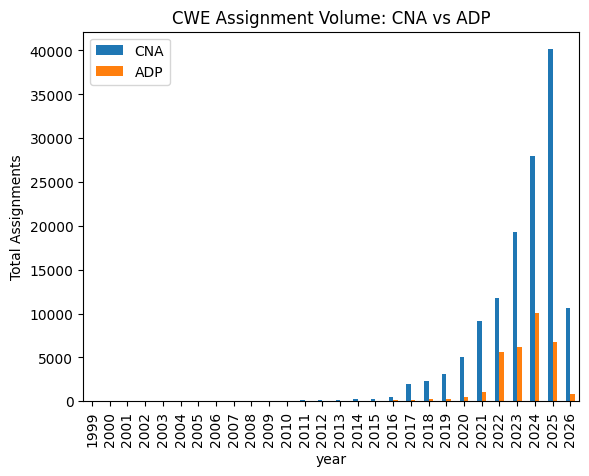

In [9]:
cwe_volume = df_cve.assign(
    CNA=df_cve['cna_cwes'].map(len), 
    ADP=df_cve['adp_cwes'].map(len)
).groupby('year')[['CNA', 'ADP']].sum()

cwe_volume.plot.bar(title='CWE Assignment Volume: CNA vs ADP', ylabel='Total Assignments');

## Metrics calculation

### Coverage

How many CVEs have a CWE associated?

In [30]:
coverage = len(df_cve[df_cve["has_cwe"]==True])/len(df_cve)
print(f"Coverage is {coverage*100:.2f}%")

Coverage is 43.23%


### Cardinality

How many CWEs are associated with a CVE on average?

In [11]:
# Get counts for valid CWEs
valid_counts = df_cve_cwe[df_cve_cwe["cwe_id"] != "CWE-noinfo"].groupby("cve_id").size()

# Reindex filling with 0 the CVE without CWEs
all_ids = df_cve_cwe["cve_id"].unique()
overall_counts = valid_counts.reindex(all_ids, fill_value=0)

mean = overall_counts.mean()
std = overall_counts.std()

print(f"Overall Cardinality (All CVEs) is {mean:.2f} ± {std:.2f}")

Overall Cardinality (All CVEs) is 0.47 ± 0.57


In [12]:
valid_counts = df_cve_cwe[df_cve_cwe["cwe_id"] != "CWE-noinfo"].groupby("cve_id").size()

mean = valid_counts.mean()
std = valid_counts.std()

print(f"Cardinality (CVEs with >=1 valid CWE) is {mean:.2f} ± {std:.2f}")

Cardinality (CVEs with >=1 valid CWE) is 1.08 ± 0.30


### Popularity

Are there CWEs that occur much more frequently in assignments?

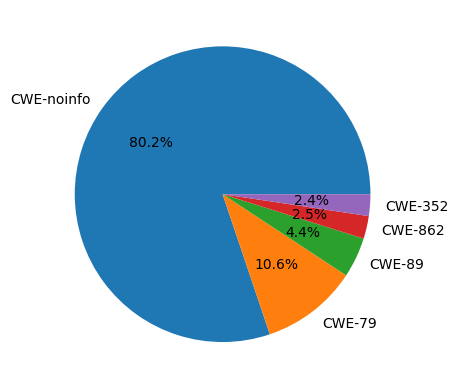

In [13]:
top_5_cwe_values = df_cve_cwe["cwe_id"].value_counts(normalize=True).head(5)
pie_5 = top_5_cwe_values.plot.pie(autopct='%1.1f%%', ylabel='') # pyright: ignore[reportCallIssue]

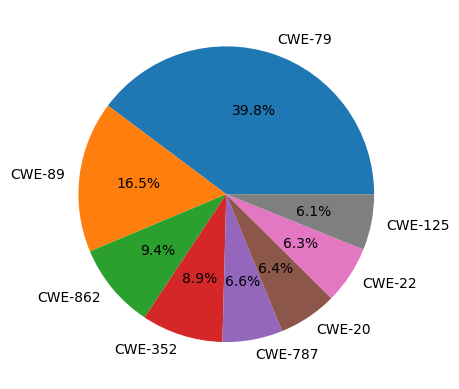

In [14]:
top_8_cwe_valid = df_cve_cwe[df_cve_cwe["cwe_id"] != "CWE-noinfo"]["cwe_id"].value_counts(normalize=True).head(8)
pie_8 = top_8_cwe_valid.plot.pie(autopct='%1.1f%%', ylabel='') # pyright: ignore[reportCallIssue]

### Temporal Trends

Is there a trend over time regarding the "density" of assignments (e.g., are modern CVEs being assigned more CWEs than older ones)?

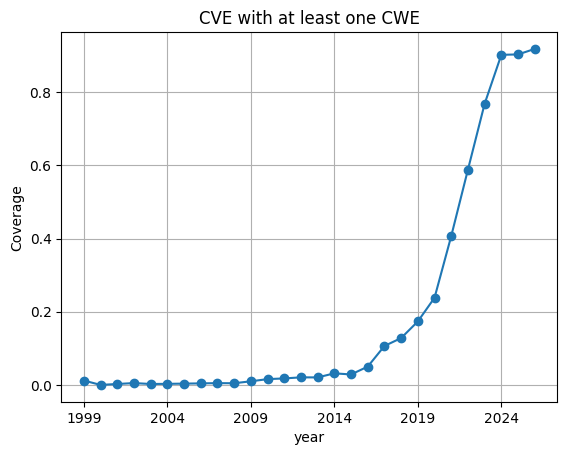

In [15]:
trend = df_cve.groupby('year')['has_cwe'].mean()
cwe_trend = trend.plot(kind='line', marker='o', grid=True, ylabel='Coverage', title='CVE with at least one CWE')

Average assigment 

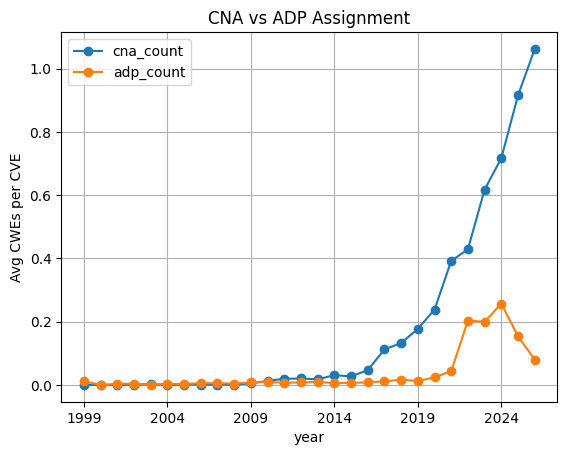

In [16]:
df_cve['cna_count'] = df_cve['cna_cwes'].str.len()
df_cve['adp_count'] = df_cve['adp_cwes'].str.len()

counts_trend = df_cve.groupby('year')[['cna_count', 'adp_count']].mean()
cna_vs_adp_trend = counts_trend.plot(kind='line', marker='o', grid=True, ylabel='Avg CWEs per CVE', title='CNA vs ADP Assignment')

### Completeness

What percentage of CVE records use "placeholder" CWEs (`CWE-noinfo`) vs. actual weakness types?

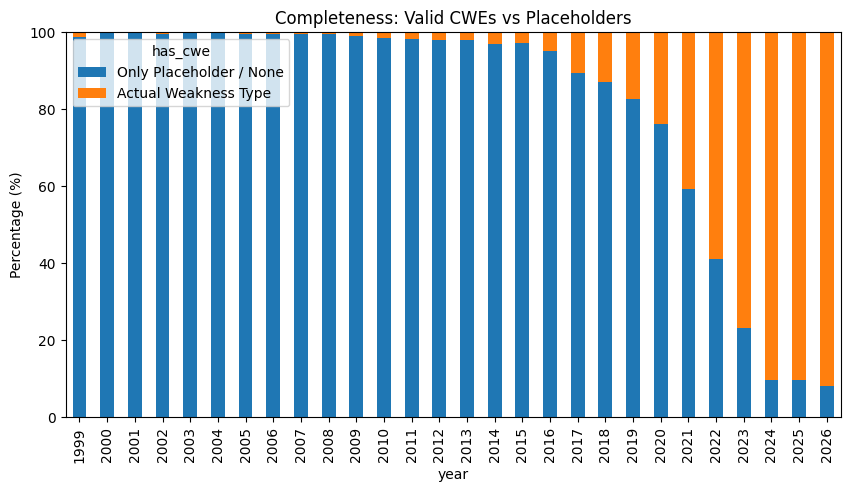

In [ ]:
# Get percentages per year
completeness = df_cve.groupby('year')['has_cwe'].value_counts(normalize=True).unstack(fill_value=0).mul(100)

completeness.rename(columns={False: 'Only Placeholder/None', True: 'CWE'}, inplace=True)
completeness_trend = completeness.plot.bar(stacked=True, figsize=(10, 5), title='Completeness: Valid CWEs vs Placeholders', ylabel='Percentage (%)')

### Abstraction Distribution